# Time Series Forecasting: Silicon Aging (Vth Drift)## ARIMA on Daily Threshold Voltage Measurements**Project:** 009 — The AI Engineering Lab  **Objective:** Forecast silicon aging degradation using classical time series.  **Advanced Concepts:** Non-stationary trends, differencing, AIC model selection, prediction intervals.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data

In [2]:
df = pd.read_csv('../data/silicon_aging_vth.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

time_col = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower() or 'day' in c.lower()]
if time_col:
    df[time_col[0]] = pd.to_datetime(df[time_col[0]])
    df = df.set_index(time_col[0])
    df = df.sort_index()

value_col = df.select_dtypes(include=[np.number]).columns[0]
ts = df[value_col].dropna()
print(f'Series length: {len(ts)}, col={value_col}')

Shape: (1095, 2)
Columns: ['date', 'vth_shift_mv']
Series length: 1095, col=vth_shift_mv


---## 3. Visualization & Stationarity

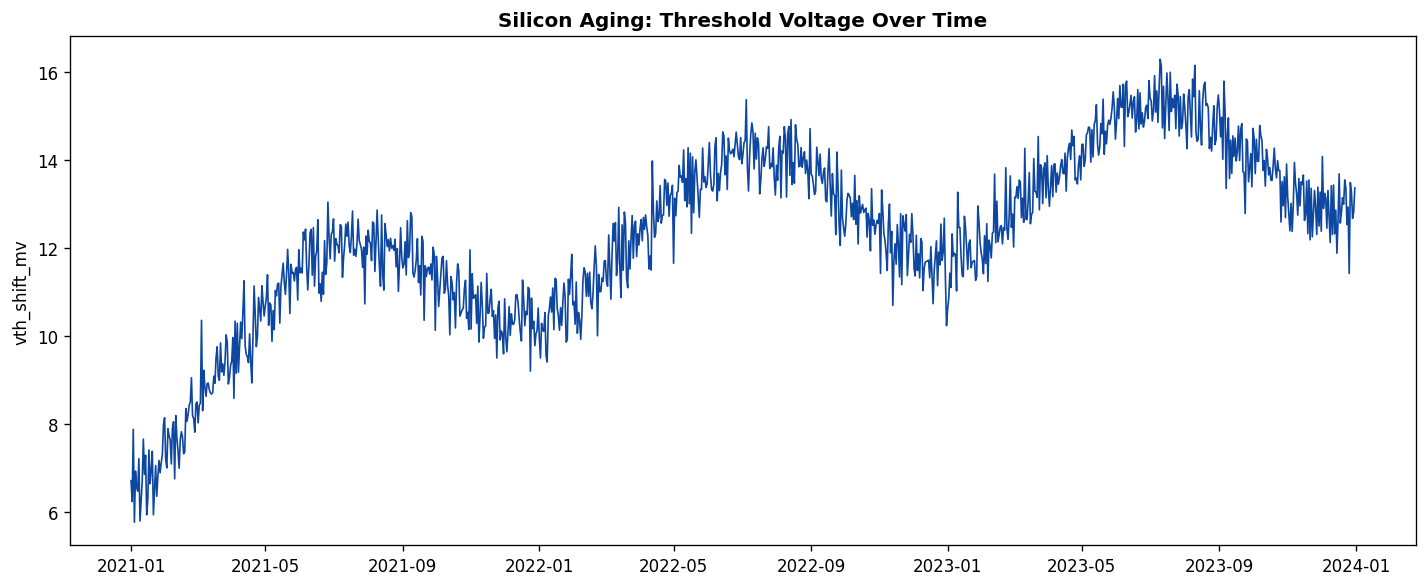

ADF Statistic: -3.3164, p-value: 0.014163
Stationary: Yes


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ts.index, ts.values, color=COLORS['primary'], linewidth=1)
ax.set_title('Silicon Aging: Threshold Voltage Over Time', fontsize=12, fontweight='bold')
ax.set_ylabel(value_col)
plt.tight_layout()
plt.savefig('../assets/proj2_silicon_aging_ts_overview.png', dpi=150, bbox_inches='tight')
plt.show()

result = adfuller(ts.values)
print(f'ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.6f}')
print(f'Stationary: {"Yes" if result[1] < 0.05 else "No"}')

---## 4. ACF/PACF

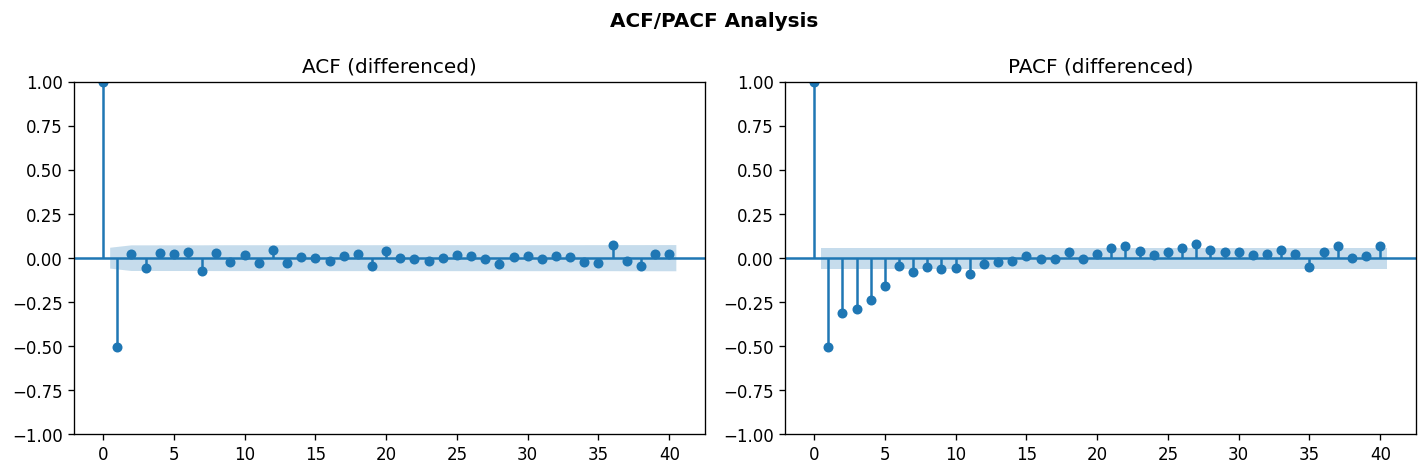

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ts_diff = ts.diff().dropna()
plot_acf(ts_diff, lags=40, ax=axes[0]); axes[0].set_title('ACF (differenced)')
plot_pacf(ts_diff, lags=40, ax=axes[1]); axes[1].set_title('PACF (differenced)')
plt.suptitle('ACF/PACF Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj2_silicon_aging_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

---## 5. ARIMA Forecast

/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/rajendarmuddasani/AIML/55_LinkedIn/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(1,1,1) AIC: 1622.1


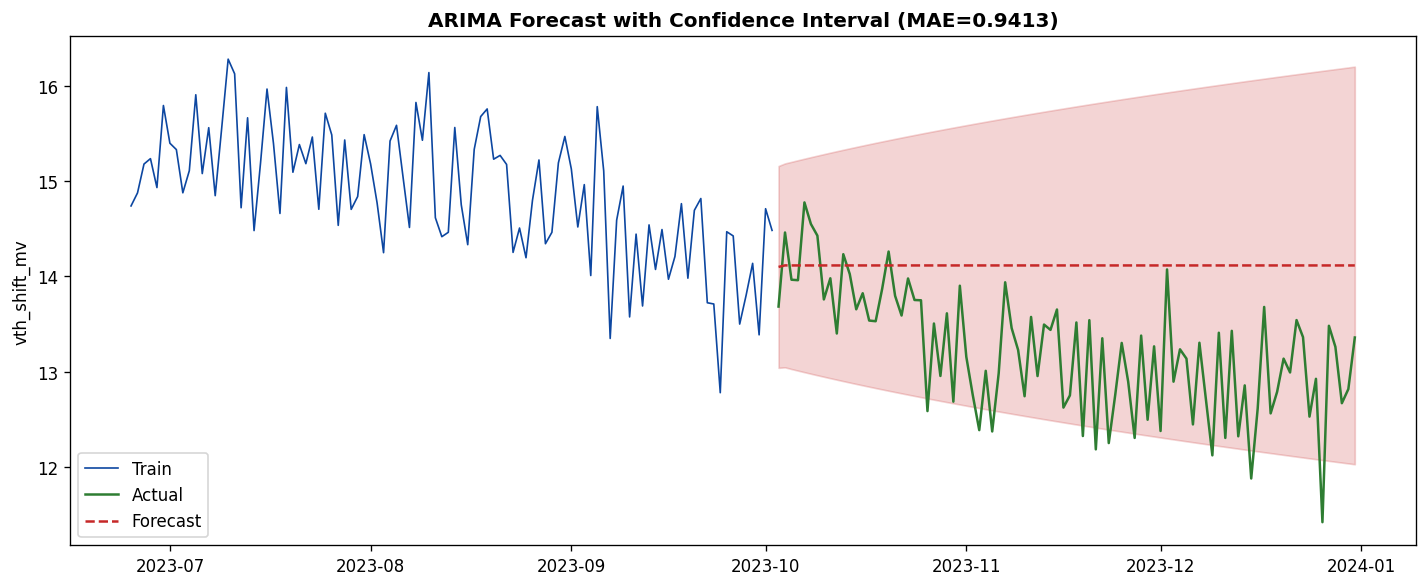

MAE: 0.9413, RMSE: 1.1064
Notebook complete.


In [5]:
n_test = min(90, len(ts) // 5)
train, test = ts.iloc[:-n_test], ts.iloc[-n_test:]

model = ARIMA(train, order=(1, 1, 1))
fit = model.fit()
print(f'ARIMA(1,1,1) AIC: {fit.aic:.1f}')

forecast_result = fit.get_forecast(steps=n_test)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

mae = mean_absolute_error(test.values, forecast.values)
rmse = np.sqrt(mean_squared_error(test.values, forecast.values))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index[-100:], train.values[-100:], color=COLORS['primary'], linewidth=1, label='Train')
ax.plot(test.index, test.values, color='#2E7D32', linewidth=1.5, label='Actual')
ax.plot(test.index, forecast.values, color=COLORS['highlight'], linewidth=1.5, linestyle='--', label='Forecast')
ax.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2, color=COLORS['highlight'])
ax.set_title(f'ARIMA Forecast with Confidence Interval (MAE={mae:.4f})', fontsize=12, fontweight='bold')
ax.legend(); ax.set_ylabel(value_col)
plt.tight_layout()
plt.savefig('../assets/proj2_silicon_aging_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'MAE: {mae:.4f}, RMSE: {rmse:.4f}')
print('Notebook complete.')